# Automatic saccade detection and visual review

**One participant per run**

This notebook reads a Neuroscan CNT recording, constructs horizontal EOG (HEOG), detects saccades in the continuous signal, and selects the first qualifying event in each target response window. It provides static and interactive review plots and exports automatic annotations.

Behavioral and CNV analyses use finalized, manually reviewed annotations. The automatic annotations generated here are proposals for visual review; they do not replace finalized annotations.

## Workflow

1. Set `PARTICIPANT_ID`, `CNT_FILE`, and `AUTOMATIC_OUTPUT_DIR`.
2. Set `RUN_DETECTION = True`, restart the kernel, and run all cells.
3. Inspect the event alignment, polarity diagnostic, overview, and individual trials.
4. Enable `SAVE_AUTOMATIC_XLSX` to export `<participant_id>_saccades_auto.xlsx`.
5. Review latency and direction in a separate copy, update detection and correctness flags as needed, and retain every trial row and its identifier. Store finalized annotations separately as `<participant_id>_saccades.xlsx` for downstream analysis.

## Signal processing and detector conventions

| Setting | Value or operation |
|---|---|
| Horizontal EOG | EOG1 − EOG2, in volts |
| Filtering | 1–40 Hz on continuous HEOG, before epoching; MNE FIR defaults |
| Smoothing for detection | 5-ms moving average |
| Velocity | Numerical derivative of the smoothed continuous signal |
| Velocity threshold | Median absolute velocity + 6 × 1.4826 × MAD of absolute velocity, estimated over the recording |
| Candidate onset | Upward crossing of the absolute-velocity threshold |
| Amplitude criterion | Absolute signal step ≥30 µV |
| Signal step | Difference between median smoothed HEOG levels in the 50 ms before and after the candidate onset |
| Refractory interval | At least 80 ms between accepted onsets |
| Response selection | First accepted onset from −400 through +600 ms relative to target onset |
| Direction | −1 = left, +1 = right; `SIGN_RIGHT = -1` maps a negative HEOG step to a rightward movement |
| Review epoch | −700 to +700 ms relative to target onset |
| Review baseline | −200 to 0 ms; applied to displayed HEOG epochs only |
| Epoch rejection by annotations | Disabled for saccade review |
| Repeated target events | MNE `event_repeated="drop"`; omitted targets are reported |

Detection runs once on the continuous HEOG. Baseline correction of the review epochs does not affect detection. The moving average uses zero padding at recording boundaries. The pre-onset amplitude window is truncated at the start; when the post-onset window reaches or exceeds the end of the recording, the final smoothed sample supplies the post-onset level. A small numerical offset (10⁻¹² V/s) is added to the velocity MAD.

The response window can include pretarget movements. If a qualifying pretarget movement occurs before a posttarget response, the earlier event is selected. The window does not cover the entire cue–target interval. The polarity diagnostic does not automatically change `SIGN_RIGHT`.

In [26]:
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError
import hashlib
import platform
import re

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import Markdown, display

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 110, "savefig.dpi": 160,
})

software_rows = [("Python", platform.python_version())]
for package in ("mne", "numpy", "pandas", "matplotlib", "openpyxl", "ipywidgets"):
    try:
        software_rows.append((package, version(package)))
    except PackageNotFoundError:
        software_rows.append((package, "not installed; optional trial browser unavailable"))
software_versions = pd.DataFrame(software_rows, columns=["software", "version"])
display(software_versions)

,software,version
0,Python,3.13.9
1,mne,1.11.0
2,numpy,2.3.5
3,pandas,2.3.3
4,matplotlib,3.10.6
5,openpyxl,3.1.5
6,ipywidgets,8.1.7


In [27]:
RUN_DETECTION = True
PARTICIPANT_ID = "Example01"
CNT_FILE = Path("Examples/EEG_example.cnt").expanduser()
AUTOMATIC_OUTPUT_DIR = Path("Saccades_detected").expanduser()
SAVE_AUTOMATIC_XLSX = False
OVERWRITE_AUTOMATIC = False
SHOW_INTERACTIVE_REVIEW = True
REVIEW_TRIAL = 0  # Zero-based trial identifier for the static view.

EOG_ANODE = "EOG1"
EOG_CATHODE = "EOG2"
SIGN_RIGHT = -1
EPOCH_TMIN, EPOCH_TMAX = -0.7, 0.7
EPOCH_BASELINE = (-0.2, 0.0)
FILTER_LOW_HZ, FILTER_HIGH_HZ = 1.0, 40.0
RESPONSE_WINDOW = (-0.4, 0.6)

DETECTOR_PARAMETERS = {
    "velocity_mad_factor": 6.0,
    "smooth_ms": 5.0,
    "refractory_ms": 80.0,
    "minimum_step_v": 30e-6,
    "step_window_ms": 50.0,
    "sign_right": SIGN_RIGHT,
}
CONDITION_ORDER = ["valid_80", "invalid_80", "valid_50", "invalid_50"]
CONDITION_LABELS = {
    "valid_80": "80% valid", "invalid_80": "80% invalid",
    "valid_50": "50% valid", "invalid_50": "50% invalid",
}
TRACE_STYLES = {
    "correct": {"color": "#28618B", "linestyle": "-", "marker": "o"},
    "error": {"color": "#B86628", "linestyle": "--", "marker": "x"},
    "undetected": {"color": "#858A90", "linestyle": ":", "marker": "o"},
}
if SAVE_AUTOMATIC_XLSX and not RUN_DETECTION:
    raise ValueError("Enable RUN_DETECTION before exporting automatic annotations.")
print("Mode:", "recording analysis" if RUN_DETECTION else "no study recording loaded")

Mode: recording analysis


## Target event dictionary

Event names are decoded from MNE's annotation mapping. Correctness is defined relative to the target stimuli.

In [28]:
EVENT_INFO = pd.DataFrame(
    [
        (20, 80, "valid",   -1, -1, "valid_80"),
        (21, 80, "invalid",  1, -1, "invalid_80"),
        (22, 50, "valid",   -1, -1, "valid_50"),
        (23, 50, "invalid",  1, -1, "invalid_50"),
        (30, 80, "valid",    1,  1, "valid_80"),
        (31, 80, "invalid", -1,  1, "invalid_80"),
        (32, 50, "valid",    1,  1, "valid_50"),
        (33, 50, "invalid", -1,  1, "invalid_50"),
    ],
    columns=["event", "probability", "validity", "cue_direction", "target_direction", "condition"],
).set_index("event")
TARGET_EVENT_NAMES = [str(event) for event in EVENT_INFO.index]
display(EVENT_INFO)

,probability,validity,cue_direction,target_direction,condition
event,,,,,
20,80,valid,-1,-1,valid_80
21,80,invalid,1,-1,invalid_80
22,50,valid,-1,-1,valid_50
23,50,invalid,1,-1,invalid_50
30,80,valid,1,1,valid_80
31,80,invalid,-1,1,invalid_80
32,50,valid,1,1,valid_50
33,50,invalid,-1,1,invalid_50


## Continuous detector

Input is a filtered, one-dimensional HEOG signal in volts. Onset indices are relative to the first sample in that array. Directions describe physical movement: −1 for left and +1 for right. The returned velocity and threshold are used directly in the review plots.

In [29]:
def detect_saccades_continuous(
    signal, sfreq, *, velocity_mad_factor=6.0, smooth_ms=5.0,
    refractory_ms=80.0, minimum_step_v=30e-6, step_window_ms=50.0,
    sign_right=-1,
):
    """Detect all qualifying onsets in continuous, filtered HEOG.

    Returns a dictionary with onset_indices, directions, velocity_v_s,
    and velocity_threshold_v_s. Onset indices are zero-based within
    signal; directions are physical left (-1) or right (+1).
    """
    signal = np.asarray(signal, dtype=float)
    if signal.ndim != 1 or signal.size < 2 or not np.isfinite(signal).all():
        raise ValueError("HEOG must be a finite one-dimensional signal with at least two samples.")
    parameters = [sfreq, velocity_mad_factor, smooth_ms, refractory_ms,
                  minimum_step_v, step_window_ms]
    if not np.isfinite(parameters).all() or any(value <= 0 for value in parameters):
        raise ValueError("Sampling rate and detector parameters must be positive and finite.")
    if sign_right not in (-1, 1):
        raise ValueError("sign_right must be -1 or +1.")

    smoothing_samples = max(1, int(round(smooth_ms / 1000 * sfreq)))
    step_samples = int(step_window_ms / 1000 * sfreq)
    refractory_samples = int(refractory_ms / 1000 * sfreq)
    if smoothing_samples > signal.size or step_samples < 1:
        raise ValueError("The signal length or sampling rate is incompatible with the detector windows.")
    smoothed = np.convolve(
        signal, np.ones(smoothing_samples) / smoothing_samples, mode="same",
    )
    velocity = np.gradient(smoothed, 1.0 / sfreq)
    absolute_velocity = np.abs(velocity)
    median_velocity = np.median(absolute_velocity)
    velocity_mad = np.median(np.abs(absolute_velocity - median_velocity)) + 1e-12
    threshold = median_velocity + velocity_mad_factor * 1.4826 * velocity_mad
    above_threshold = absolute_velocity > threshold
    candidates = np.flatnonzero(~above_threshold[:-1] & above_threshold[1:]) + 1

    onsets, directions = [], []
    last_onset = -10**9
    for onset in candidates:
        if onset - last_onset < refractory_samples:
            continue
        pre_level = np.median(smoothed[max(0, onset - step_samples):onset])
        post_level = (
            np.median(smoothed[onset:onset + step_samples])
            if onset + step_samples < len(smoothed) else smoothed[-1]
        )
        step = post_level - pre_level
        if abs(step) >= minimum_step_v:
            onsets.append(onset)
            directions.append(sign_right if step > 0 else -sign_right)
            last_onset = onset

    return {
        "onset_indices": np.asarray(onsets, dtype=int),
        "directions": np.asarray(directions, dtype=int),
        "velocity_v_s": velocity,
        "velocity_threshold_v_s": float(threshold),
    }

## Prepare continuous HEOG and target epochs

HEOG is constructed and filtered before detection. Target epochs are then extracted for review and baseline-corrected for display. The velocity shown for each trial is sampled from the continuous detector output.

The target-event QC table identifies retained, repeated, and incomplete target epochs. Check omitted targets before aligning reviewed annotations with EEG analyses; `Event_alignment` retains the target sample and annotation-event index for each exported trial.

In [30]:
def prepare_heog_epochs(raw):
    """Return review epochs, event QC, continuous detections, and epoch velocity."""
    missing = {EOG_ANODE, EOG_CATHODE} - set(raw.ch_names)
    if missing:
        raise ValueError(f"Missing EOG channels: {sorted(missing)}")
    raw_bip = mne.set_bipolar_reference(
        raw, anode=EOG_ANODE, cathode=EOG_CATHODE,
        ch_name="HEOG", drop_refs=True, copy=True,
    )
    raw_bip.set_channel_types({"HEOG": "eog"})
    raw_heog = raw_bip.copy().pick(["HEOG"])
    raw_heog.filter(FILTER_LOW_HZ, FILTER_HIGH_HZ, picks=["HEOG"])
    sfreq = float(raw_heog.info["sfreq"])
    detections = detect_saccades_continuous(
        raw_heog.get_data(picks=["HEOG"])[0], sfreq, **DETECTOR_PARAMETERS,
    )
    events, event_id = mne.events_from_annotations(raw_heog)
    target_ids = {name: event_id[name] for name in TARGET_EVENT_NAMES if name in event_id}
    if not target_ids:
        raise ValueError("No target annotations match the configured event names.")
    epochs = mne.Epochs(
        raw_heog, events, event_id=target_ids,
        tmin=EPOCH_TMIN, tmax=EPOCH_TMAX,
        picks=["HEOG"], reject_by_annotation=False,
        event_repeated="drop", baseline=EPOCH_BASELINE, preload=True,
    )
    if len(epochs) == 0:
        raise ValueError("No complete target epochs were retained.")
    sample_indices = (
        epochs.events[:, 0, None] - raw_heog.first_samp
        + np.rint(epochs.times * sfreq).astype(int)[None, :]
    )
    velocity_epochs = detections["velocity_v_s"][sample_indices]

    inverse = {value: name for name, value in event_id.items()}
    selected = set(int(index) for index in epochs.selection)
    rows = []
    for index, event in enumerate(events):
        name = inverse[int(event[2])]
        if name not in TARGET_EVENT_NAMES:
            continue
        rows.append({
            "annotation_event_index": index,
            "event": int(name), "target_sample": int(event[0]),
            "epoch_retained": index in selected,
            "drop_reason": "; ".join(epochs.drop_log[index]),
        })
    return epochs, pd.DataFrame(rows), detections, velocity_epochs


def polarity_diagnostic(data, times, event_names):
    """Estimate polarity from valid targets without changing SIGN_RIGHT."""
    names = np.asarray(event_names).astype(str)
    left = np.isin(names, ["20", "22"])
    right = np.isin(names, ["30", "32"])
    post = (times >= 0.1) & (times <= 0.4)
    if not left.any() or not right.any() or not post.any():
        return {"estimated_sign_right": np.nan, "configured_sign_right": SIGN_RIGHT,
                "right_minus_left_uv": np.nan, "status": "insufficient valid-target data"}
    difference = data[right].mean(axis=0)[post].mean() - data[left].mean(axis=0)[post].mean()
    estimate = +1 if difference > 0 else -1
    status = "agrees with fixed sign" if estimate == SIGN_RIGHT else "differs: inspect recording polarity"
    if difference == 0:
        status = "zero difference: polarity estimate uninformative"
    return {"estimated_sign_right": estimate, "configured_sign_right": SIGN_RIGHT,
            "right_minus_left_uv": difference * 1e6, "status": status}

## Build automatic annotations

For each retained target epoch, select the first continuous detection in `RESPONSE_WINDOW`. `trial` is the zero-based position in the retained target-epoch array and must not be renumbered during review. Trials without a detection retain missing latency and direction 0.

This notebook does not assign latency categories. Downstream analyses calculate those categories from the finalized, manually reviewed latency.

In [31]:
def make_automatic_annotations(
    target_samples, event_names, saccade_samples, directions, sfreq, *, response_window,
):
    """Select the first detection in each target window; all samples are absolute."""
    target_samples = np.asarray(target_samples, dtype=int)
    saccade_samples = np.asarray(saccade_samples, dtype=int)
    directions = np.asarray(directions, dtype=int)
    if len(target_samples) != len(event_names):
        raise ValueError("Target sample count does not match target-event count.")
    if directions.shape != saccade_samples.shape or np.any(np.diff(saccade_samples) < 0):
        raise ValueError("Saccade samples must be sorted and have matching directions.")
    if len(response_window) != 2 or response_window[0] > response_window[1]:
        raise ValueError("Specify an ordered two-value response window in seconds.")
    lower = int(np.ceil(response_window[0] * sfreq - 1e-9))
    upper = int(np.floor(response_window[1] * sfreq + 1e-9))
    records = []
    for trial, (target_sample, name) in enumerate(zip(target_samples, event_names)):
        event = int(name)
        if event not in EVENT_INFO.index:
            raise ValueError(f"Unknown target event: {name}")
        info = EVENT_INFO.loc[event]
        index = np.searchsorted(saccade_samples, target_sample + lower, side="left")
        detected = bool(index < len(saccade_samples)
                        and saccade_samples[index] <= target_sample + upper)
        latency_ms = ((saccade_samples[index] - target_sample) * 1000.0 / sfreq
                      if detected else np.nan)
        direction = int(directions[index]) if detected else 0
        expected = int(info["target_direction"])
        records.append({
            "trial": trial, "event": event, "condition": info["condition"],
            "side": "left" if expected < 0 else "right",
            "latency_ms": latency_ms, "direction": direction, "expected": expected,
            "detected": detected, "correct": detected and direction == expected,
        })
    return pd.DataFrame(records)


def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

## Diagnostic plots

The overview shows all trials by condition and target side on a common amplitude scale. Individual-trial plots show baseline-corrected HEOG and the detector's smoothed continuous velocity. Shading marks the response window; dashed horizontal lines show the recording-wide velocity threshold. The signal-step criterion and refractory interval also contribute to detection.

Calculations use volts and seconds; plots use microvolts and milliseconds. Colors, line styles, symbols, and text distinguish correct, incorrectly directed, and undetected responses.

In [32]:
def trial_status(row):
    return "undetected" if not bool(row["detected"]) else ("correct" if bool(row["correct"]) else "error")


def plot_trial(
    table, data, times, trial_id, *, velocity_data, velocity_threshold,
    response_window, title_prefix="Automatic detection",
):
    selected = table.loc[table["trial"].eq(trial_id)]
    if len(selected) != 1:
        raise ValueError(f"Expected one annotation for trial {trial_id}.")
    row = selected.iloc[0]
    trace = data[int(row["trial"])]
    velocity = velocity_data[int(row["trial"])]
    status = trial_status(row); style = TRACE_STYLES[status]
    fig, axes = plt.subplots(2, 1, figsize=(10, 5.6), sharex=True, constrained_layout=True)
    times_ms = times * 1000
    axes[0].plot(times_ms, trace * 1e6, color=style["color"], ls=style["linestyle"], lw=1.3)
    axes[1].plot(times_ms, velocity * 1e6, color="#343A40", lw=1)
    search = response_window
    threshold = velocity_threshold * 1e6
    for value in (-threshold, threshold):
        axes[1].axhline(value, color="#B86628", ls="--", lw=1)
    for ax in axes:
        ax.axvspan(search[0] * 1000, search[1] * 1000, color="#ECEFF1", alpha=0.55, zorder=0)
        ax.axvline(0, color="#222222", ls="--", lw=1)
        ax.grid(axis="y", color="#E3E5E7", lw=0.5)
        ax.set_xlim(times_ms[0], times_ms[-1])
    if row["detected"]:
        onset_ms = float(row["latency_ms"])
        index = np.argmin(np.abs(times_ms - onset_ms))
        axes[0].plot(onset_ms, trace[index] * 1e6, marker=style["marker"], color=style["color"], ms=7, mew=1.5)
        for ax in axes:
            ax.axvline(onset_ms, color=style["color"], ls=":", lw=1)
        response = f"onset {onset_ms:.1f} ms · direction {int(row['direction']):+d} · {status}"
    else:
        response = "no qualifying saccade detected"
    axes[0].set_ylabel("HEOG (µV)")
    axes[1].set_ylabel("Velocity (µV/s)")
    axes[1].set_xlabel("Time relative to target onset (ms)")
    fig.suptitle(f"{title_prefix} · trial {trial_id} · event {int(row['event'])} · target {row['side']}\n{response}", fontsize=11)
    return fig


def plot_overview(table, data, times):
    fig, axes = plt.subplots(4, 2, figsize=(11, 11), sharex=True, sharey=True)
    for row_index, condition in enumerate(CONDITION_ORDER):
        for col_index, side in enumerate(("left", "right")):
            ax = axes[row_index, col_index]
            subset = table.loc[table["condition"].eq(condition) & table["side"].eq(side)]
            for _, row in subset.iterrows():
                trace = data[int(row["trial"])] * 1e6
                style = TRACE_STYLES[trial_status(row)]
                ax.plot(times * 1000, trace, color=style["color"], ls=style["linestyle"], alpha=0.4, lw=0.75)
                if row["detected"]:
                    index = np.argmin(np.abs(times * 1000 - row["latency_ms"]))
                    ax.plot(row["latency_ms"], trace[index], marker=style["marker"], color=style["color"], ms=3)
            if not subset.empty:
                ax.plot(times * 1000, data[subset["trial"].to_numpy(dtype=int)].mean(axis=0) * 1e6, color="#222222", lw=1.5)
            n_detected = int(subset["detected"].sum())
            n_errors = int((subset["detected"] & ~subset["correct"]).sum())
            ax.set_title(f"{CONDITION_LABELS[condition]} · target {side}\nn = {len(subset)}, detected = {n_detected}, errors = {n_errors}", fontsize=10)
            ax.axvline(0, color="#222222", ls="--", lw=0.8)
            ax.set_xlim(times[0] * 1000, times[-1] * 1000)
            if col_index == 0: ax.set_ylabel("HEOG (µV)")
            if row_index == 3: ax.set_xlabel("Time relative to target onset (ms)")
    handles = [Line2D([], [], color=style["color"], ls=style["linestyle"], label=label) for label, style in TRACE_STYLES.items()]
    handles.append(Line2D([], [], color="#222222", lw=1.5, label="mean trace"))
    fig.suptitle("Automatic saccade annotations by condition and target side", y=0.995, fontsize=12)
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.973), ncol=4, frameon=False)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    return fig

## Run detection on one recording

The source file hash, sampling rate, first sample, target-event selection, and detector parameters are exported with the annotations. Inspect omitted target events and the polarity diagnostic before review.

In [33]:
automatic_annotations = None
heog_epochs = None
recording_data = None
recording_velocity = None
continuous_detections = None
recording_times = None
event_alignment = None
target_event_qc = None
recording_metadata = None
polarity_table = None

if RUN_DETECTION:
    if PARTICIPANT_ID == "PARTICIPANT_ID" or not re.fullmatch(r"[A-Za-z0-9][A-Za-z0-9_-]*", PARTICIPANT_ID):
        raise ValueError("Set PARTICIPANT_ID to a pseudonymous participant identifier.")
    if not CNT_FILE.is_file():
        raise FileNotFoundError(f"Set CNT_FILE to the recording: {CNT_FILE}")
    raw_eog = mne.io.read_raw_cnt(CNT_FILE, eog=[EOG_ANODE, EOG_CATHODE], preload=True)
    (heog_epochs, target_event_qc, continuous_detections,
     recording_velocity) = prepare_heog_epochs(raw_eog)
    recording_sfreq = float(heog_epochs.info["sfreq"])
    recording_times = heog_epochs.times.copy()
    recording_data = heog_epochs.get_data()[:, 0, :]
    inverse = {value: name for name, value in heog_epochs.event_id.items()}
    recording_event_names = [inverse[int(code)] for code in heog_epochs.events[:, 2]]
    saccade_samples = continuous_detections["onset_indices"] + int(raw_eog.first_samp)
    automatic_annotations = make_automatic_annotations(
        heog_epochs.events[:, 0], recording_event_names, saccade_samples,
        continuous_detections["directions"], recording_sfreq,
        response_window=RESPONSE_WINDOW,
    )
    event_alignment = pd.DataFrame({
        "trial": automatic_annotations["trial"],
        "event": automatic_annotations["event"],
        "target_sample": heog_epochs.events[:, 0],
        "annotation_event_index": heog_epochs.selection,
        "sfreq": recording_sfreq, "first_samp": int(raw_eog.first_samp),
    })
    polarity_table = pd.DataFrame([polarity_diagnostic(recording_data, recording_times, recording_event_names)])
    recording_metadata = pd.DataFrame({
        "field": ["participant_id", "cnt_file_name", "cnt_sha256", "sfreq_hz", "first_samp", "n_target_annotations", "n_retained_target_epochs", "n_continuous_detections", "velocity_threshold_v_s", "annotation_state"],
        "value": [PARTICIPANT_ID, CNT_FILE.name, sha256_file(CNT_FILE), recording_sfreq, int(raw_eog.first_samp), len(target_event_qc), len(automatic_annotations), len(saccade_samples), continuous_detections["velocity_threshold_v_s"], "automatic_unreviewed"],
    })
    counts = automatic_annotations.groupby("condition").agg(n_trials=("trial", "size"), n_detected=("detected", "sum")).reindex(CONDITION_ORDER)
    counts["n_not_detected"] = counts["n_trials"] - counts["n_detected"]
    display(counts)
    display(polarity_table)
    dropped_targets = target_event_qc.loc[~target_event_qc["epoch_retained"]]
    if not dropped_targets.empty:
        display(Markdown("**Target annotations without retained epochs:** check these before aligning reviewed annotations with EEG events."))
        display(dropped_targets.head(15))
    display(automatic_annotations.head(10))
else:
    display(Markdown("no CNT recording has been read. Configure the recording and enable `RUN_DETECTION` to analyze study data."))

/var/folders/3b/c6nr_g7j0416sc4bbw88w_cm0000gn/T/ipykernel_39596/3342300297.py:17: RuntimeWarning:   Could not parse meas date from the header. Setting to None.
  raw_eog = mne.io.read_raw_cnt(CNT_FILE, eog=[EOG_ANODE, EOG_CATHODE], preload=True)


Reading 0 ... 1472159  =      0.000 ...  1472.159 secs...
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=1472160
    Range : 0 ... 1472159 =      0.000 ...  1472.159 secs
Ready.
Added the following bipolar channels:
HEOG
No data channels found. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 3301 samples (3.301 s)

Used Annotations descriptions: [np.str_('1'), np.str_('12')

,n_trials,n_detected,n_not_detected
condition,,,
valid_80,91,91,0
invalid_80,25,25,0
valid_50,54,54,0
invalid_50,55,55,0


,estimated_sign_right,configured_sign_right,right_minus_left_uv,status
0,-1,-1,-127.699854,agrees with fixed sign


,trial,event,condition,side,latency_ms,direction,expected,detected,correct
0,0,30,valid_80,right,208.0,1,1,True,True
1,1,30,valid_80,right,203.0,1,1,True,True
2,2,33,invalid_50,right,218.0,1,1,True,True
3,3,22,valid_50,left,228.0,-1,-1,True,True
4,4,30,valid_80,right,201.0,1,1,True,True
5,5,23,invalid_50,left,199.0,-1,-1,True,True
6,6,31,invalid_80,right,228.0,1,1,True,True
7,7,22,valid_50,left,245.0,-1,-1,True,True
8,8,30,valid_80,right,154.0,1,1,True,True
9,9,30,valid_80,right,-46.0,1,1,True,True


## Recording overview and trial view

All trials appear in the overview. Change `REVIEW_TRIAL` in the configuration cell and rerun the static view to inspect any zero-based trial identifier. This view works without widget support.

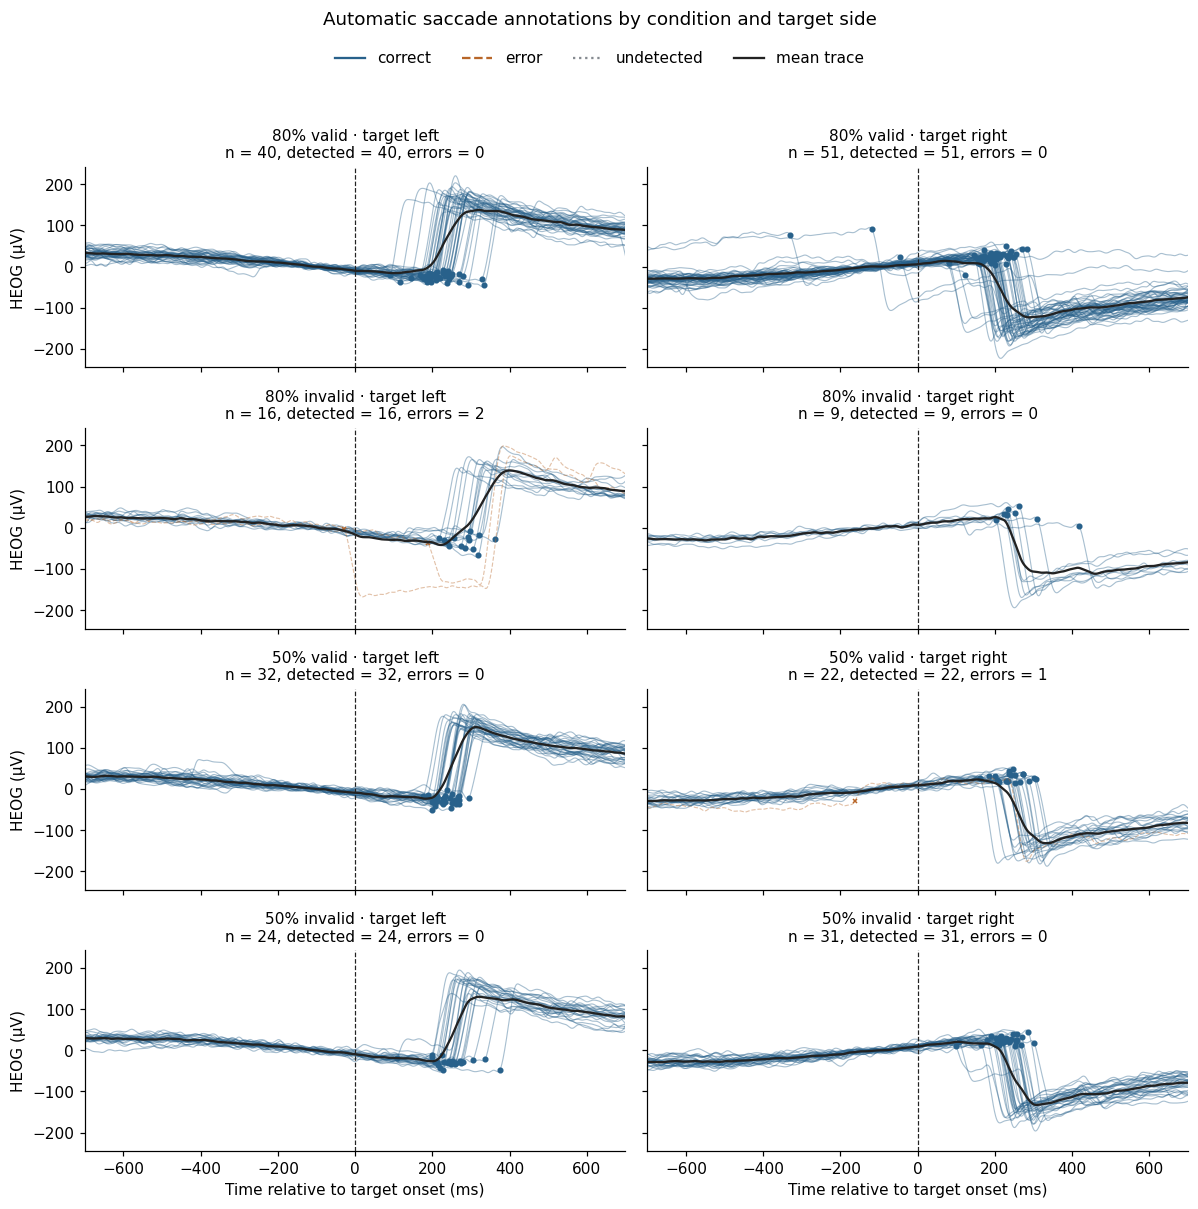

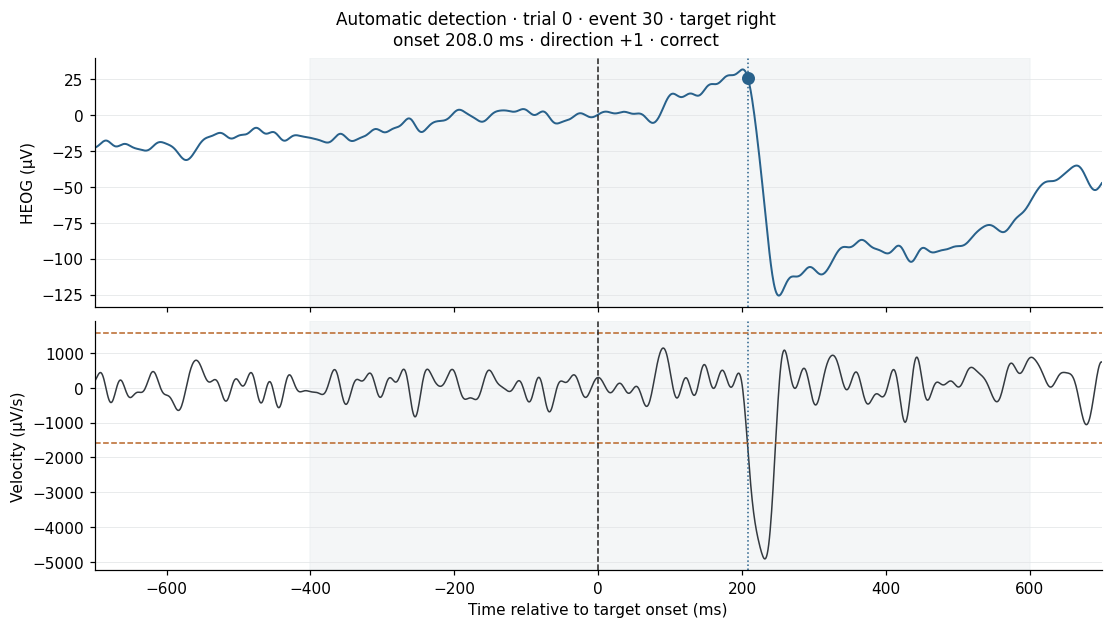

In [34]:
if automatic_annotations is not None:
    overview_figure = plot_overview(automatic_annotations, recording_data, recording_times)
    display(overview_figure)
    plt.close(overview_figure)
    trial_figure = plot_trial(
        automatic_annotations, recording_data, recording_times, REVIEW_TRIAL,
        velocity_data=recording_velocity,
        velocity_threshold=continuous_detections["velocity_threshold_v_s"],
        response_window=RESPONSE_WINDOW,
    )
    display(trial_figure)
    plt.close(trial_figure)

## Interactive trial browser

Use the condition selector, slider, or Previous/Next buttons. The browser supports inline Matplotlib figures through `ipywidgets` and does not rely on keyboard events in a static plot. The controls inspect automatic detections; edits are made in a separate reviewed Excel copy. Widget rendering depends on the local Jupyter frontend. If controls do not appear, use the static trial view above.

In [35]:
def create_trial_browser(
    table, data, times, *, velocity_data, velocity_threshold, response_window,
):
    try:
        import ipywidgets as widgets
    except ImportError:
        print("ipywidgets is not installed; use REVIEW_TRIAL and the static view.")
        return None
    condition = widgets.Dropdown(options=[("All conditions", "all")] + [(CONDITION_LABELS[key], key) for key in CONDITION_ORDER], description="Condition:")
    slider = widgets.IntSlider(value=0, min=0, max=len(table)-1, description="Position:", continuous_update=False)
    previous = widgets.Button(description="Previous")
    next_button = widgets.Button(description="Next")
    output = widgets.Output()
    state = {"trial_ids": table["trial"].to_list(), "updating": False}

    def draw(change=None):
        if state["updating"]: return
        with output:
            output.clear_output(wait=True)
            if not state["trial_ids"]:
                print("No trials for this condition.")
                return
            trial_id = state["trial_ids"][slider.value]
            print(f"Position {slider.value + 1}/{len(state['trial_ids'])}; Excel trial identifier {trial_id}")
            fig = plot_trial(
                table, data, times, trial_id, velocity_data=velocity_data,
                velocity_threshold=velocity_threshold, response_window=response_window,
            )
            display(fig)
            plt.close(fig)

    def change_condition(change):
        state["updating"] = True
        subset = table if condition.value == "all" else table.loc[table["condition"].eq(condition.value)]
        state["trial_ids"] = subset["trial"].to_list()
        slider.value = 0
        slider.max = max(0, len(state["trial_ids"]) - 1)
        slider.disabled = not bool(state["trial_ids"])
        state["updating"] = False
        draw()

    condition.observe(change_condition, names="value")
    slider.observe(draw, names="value")
    previous.on_click(lambda button: setattr(slider, "value", max(0, slider.value - 1)))
    next_button.on_click(lambda button: setattr(slider, "value", min(slider.max, slider.value + 1)))
    browser = widgets.VBox([condition, widgets.HBox([previous, next_button]), slider, output])
    display(browser)
    draw()
    return browser

trial_browser = None
if automatic_annotations is not None and SHOW_INTERACTIVE_REVIEW:
    trial_browser = create_trial_browser(
        automatic_annotations, recording_data, recording_times,
        velocity_data=recording_velocity,
        velocity_threshold=continuous_detections["velocity_threshold_v_s"],
        response_window=RESPONSE_WINDOW,
    )

## Export automatic annotations

The output workbook contains:

- **Saccades:** automatic annotations; this is the first worksheet.
- **Event_alignment:** links trial identifiers to target samples and the annotation-event indices. Sample indices refer to this CNT recording's sampling grid; do not equate them with resampled EEG indices without checking the time base.
- **Target_event_QC:** retained and dropped target annotations.
- **Recording_metadata**, **Detector_parameters**, **Software_versions**, **Polarity_check**, and **Event_dictionary**.

In [36]:
def export_automatic_annotations(annotations, alignment, target_qc, metadata, polarity, output_dir, participant_id, overwrite=False):
    output_dir = Path(output_dir).expanduser()
    if "PATH_TO_" in str(output_dir):
        raise ValueError("Replace AUTOMATIC_OUTPUT_DIR before exporting.")
    if not re.fullmatch(r"[A-Za-z0-9][A-Za-z0-9_-]*", participant_id):
        raise ValueError("Use a valid pseudonymous participant ID.")
    output_file = output_dir / f"{participant_id}_saccades_auto.xlsx"
    if output_file.exists() and not overwrite:
        raise FileExistsError(f"Automatic output already exists: {output_file.name}")
    output_dir.mkdir(parents=True, exist_ok=True)
    parameters = {
        "eog_anode": EOG_ANODE, "eog_cathode": EOG_CATHODE,
        "epoch_tmin_s": EPOCH_TMIN, "epoch_tmax_s": EPOCH_TMAX,
        "review_epoch_baseline_s": EPOCH_BASELINE,
        "response_window_s": RESPONSE_WINDOW,
        "response_selection": "first accepted onset within the inclusive response window",
        "filter_low_hz": FILTER_LOW_HZ, "filter_high_hz": FILTER_HIGH_HZ,
        "filter_application": "continuous HEOG before detection and epoching; MNE FIR defaults",
        "epoch_reject_by_annotation": False, "event_repeated": "drop",
        **DETECTOR_PARAMETERS,
    }
    parameter_table = pd.DataFrame([(key, repr(value)) for key, value in parameters.items()], columns=["parameter", "value"])
    with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
        annotations.to_excel(writer, sheet_name="Saccades", index=False)
        alignment.to_excel(writer, sheet_name="Event_alignment", index=False)
        target_qc.to_excel(writer, sheet_name="Target_event_QC", index=False)
        metadata.to_excel(writer, sheet_name="Recording_metadata", index=False)
        parameter_table.to_excel(writer, sheet_name="Detector_parameters", index=False)
        software_versions.to_excel(writer, sheet_name="Software_versions", index=False)
        polarity.to_excel(writer, sheet_name="Polarity_check", index=False)
        EVENT_INFO.reset_index().to_excel(writer, sheet_name="Event_dictionary", index=False)
        worksheet = writer.sheets["Saccades"]
        worksheet.freeze_panes = "A2"
        worksheet.auto_filter.ref = worksheet.dimensions
        from openpyxl.styles import PatternFill
        from openpyxl.utils import get_column_letter
        for index, name in enumerate(annotations.columns, start=1):
            worksheet.column_dimensions[get_column_letter(index)].width = max(13, len(name) + 2)
            if name in ("latency_ms", "direction"):
                for row in worksheet.iter_rows(min_row=2, min_col=index, max_col=index):
                    row[0].fill = PatternFill(fill_type="solid", fgColor="FFF2CC")
    return output_file

if SAVE_AUTOMATIC_XLSX:
    if automatic_annotations is None:
        raise RuntimeError("Run detection before exporting.")
    automatic_file = export_automatic_annotations(
        automatic_annotations, event_alignment, target_event_qc, recording_metadata,
        polarity_table, AUTOMATIC_OUTPUT_DIR, PARTICIPANT_ID, OVERWRITE_AUTOMATIC,
    )
    print(f"Automatic, unreviewed annotations saved: {automatic_file}")
else:
    print("Export disabled; no Excel file written.")

Export disabled; no Excel file written.
